In [16]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/operator_experiment_5'

errors_df = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])
entries_df = pd.read_csv(os.path.join(dir, 'entries.csv')).drop(columns=['Unnamed: 0'])
rps_df = pd.read_csv(os.path.join(dir, 'rps.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

config

errors_df

,1,10,50,88
0,26.996884,14.213031,22.863975,22.322435
1,26.981145,13.759590,23.399945,20.905739
2,27.068175,13.984787,22.546318,22.585291
3,26.464834,14.003475,22.594046,22.479866
4,26.253993,13.889834,22.798950,23.033522
5,25.442035,13.585615,22.730693,21.079087
6,26.637141,13.887264,22.947313,22.661226
7,25.996011,13.983194,23.249437,22.028365
8,27.391523,14.059497,22.599211,22.052174
9,26.655075,13.697020,22.386843,22.493687


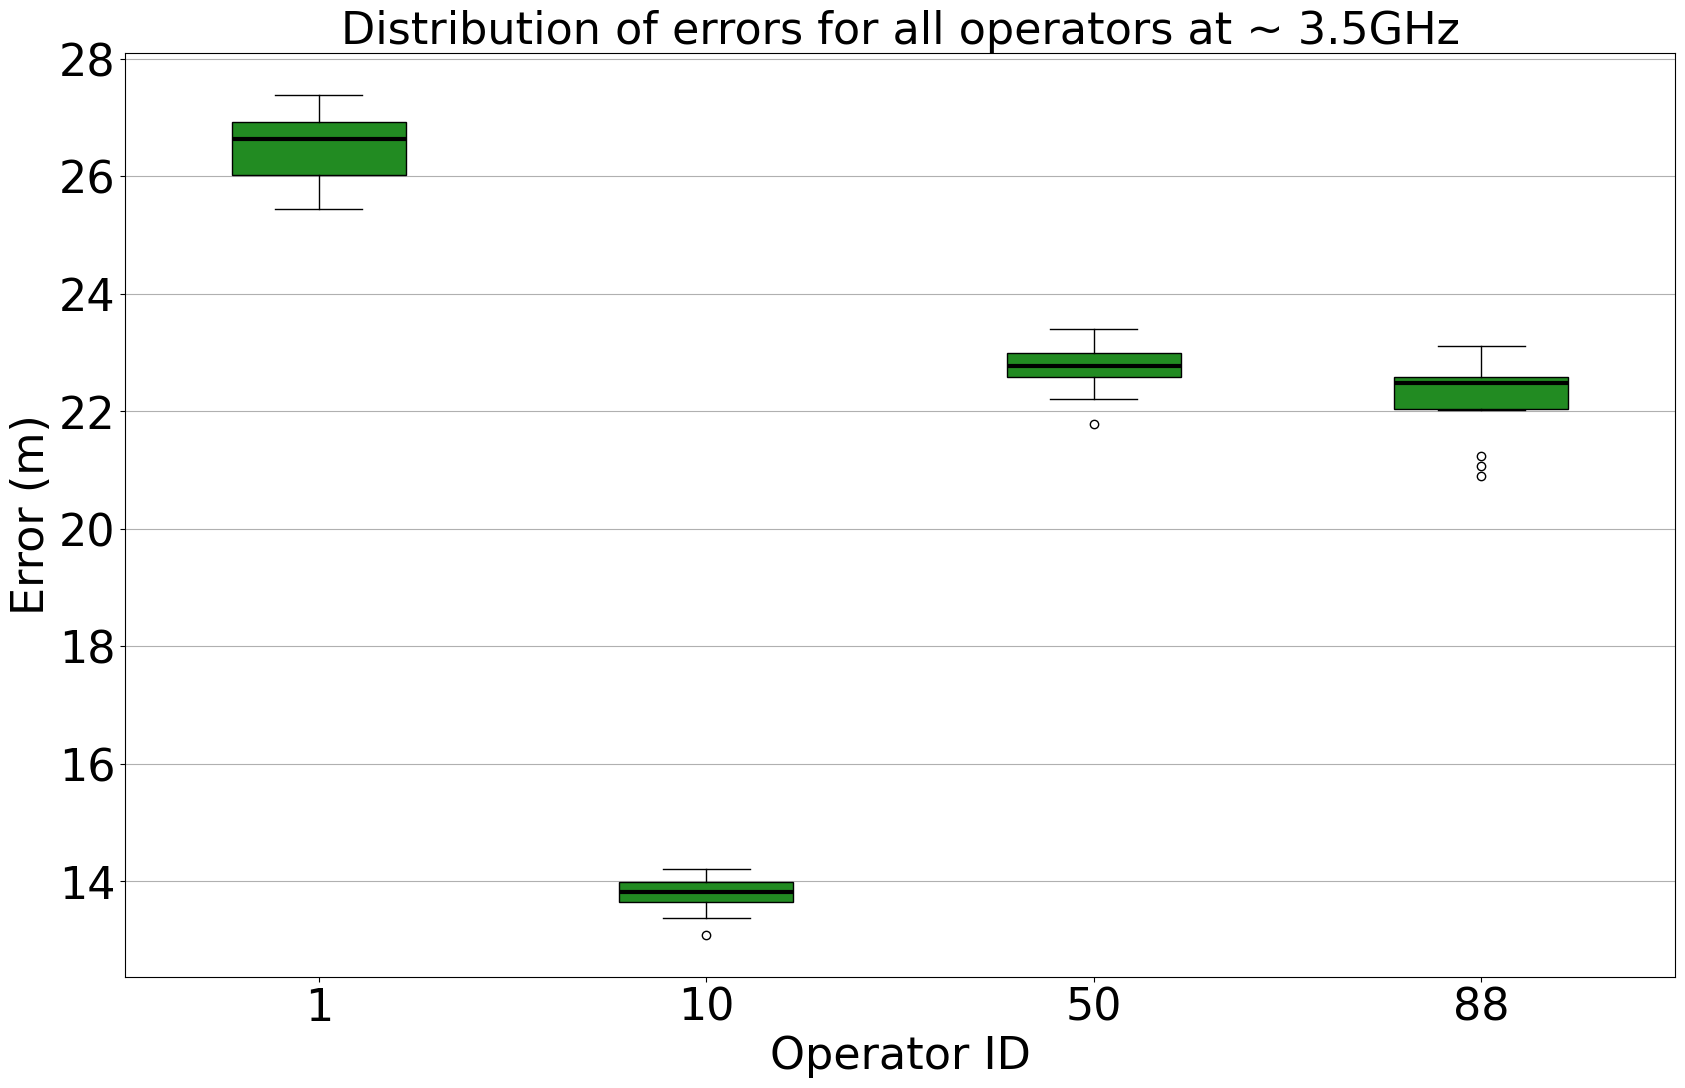

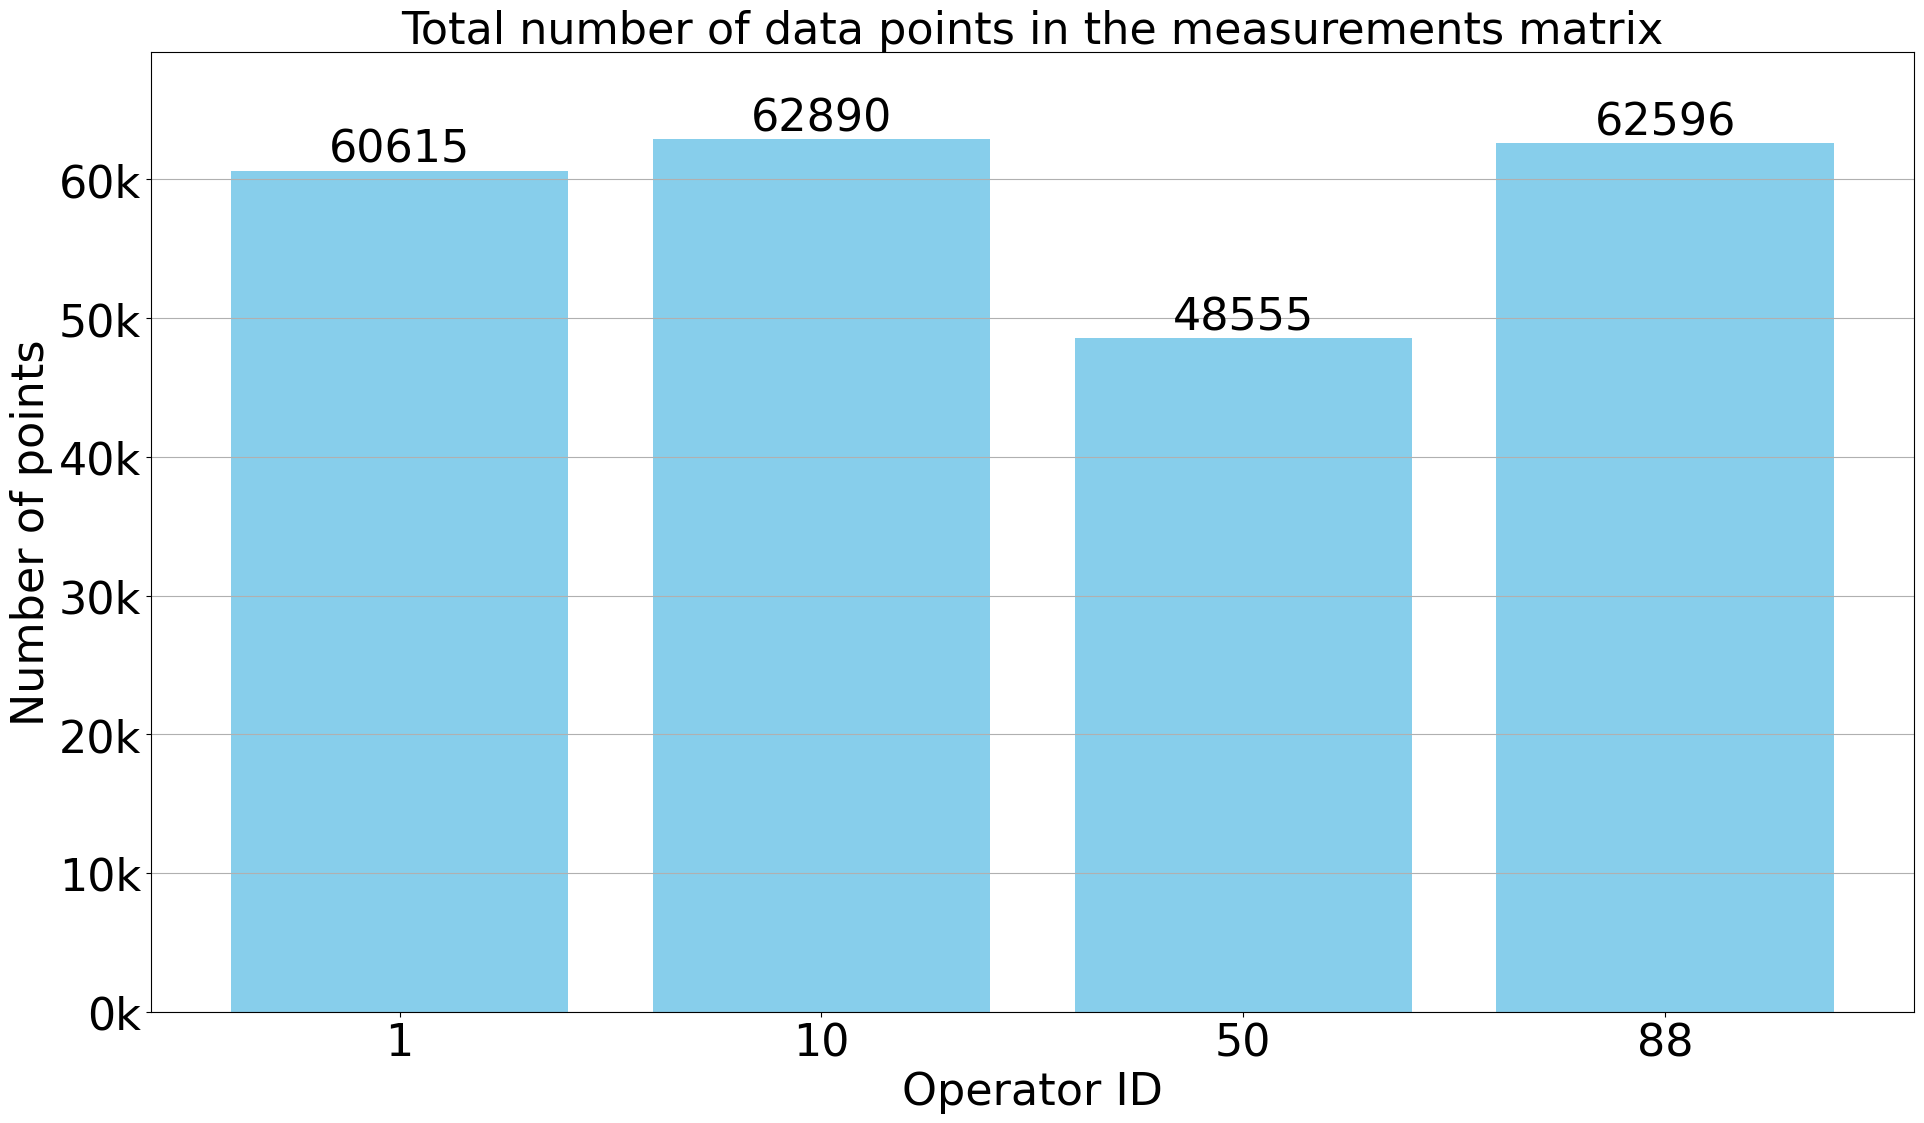

,1,10,50,88
0,12403,12609,12613,12616


In [17]:
from scripts.plotting import *

make_boxplot(
    df=errors_df[['1', '10', '50', '88']],
    x_label='Operator ID',
    y_label='Error (m)',
    title='Distribution of errors for all operators at ~ 3.5GHz',
)

make_barplot(
    df=entries_df,
    x_label='Operator ID',
    y_label='Number of points',
    title='Total number of data points in the measurements matrix',
    annotate=True,
    y_formatter=lambda x, pos: f"{x / 1000:.0f}k"

)
#
# make_barplot(
#     df=rps_df,
#     x_label='Operator ID',
#     y_label='Number of points',
#     title='Total number of valid reference points',
#     y_limit=(33100, 33600),
#     annotate=True,
#
# )

rps_df

        error   entries
1   41.208483   37051.0
10  12.711193  111287.0
50  21.144803  100235.0
88  22.849882   86445.0


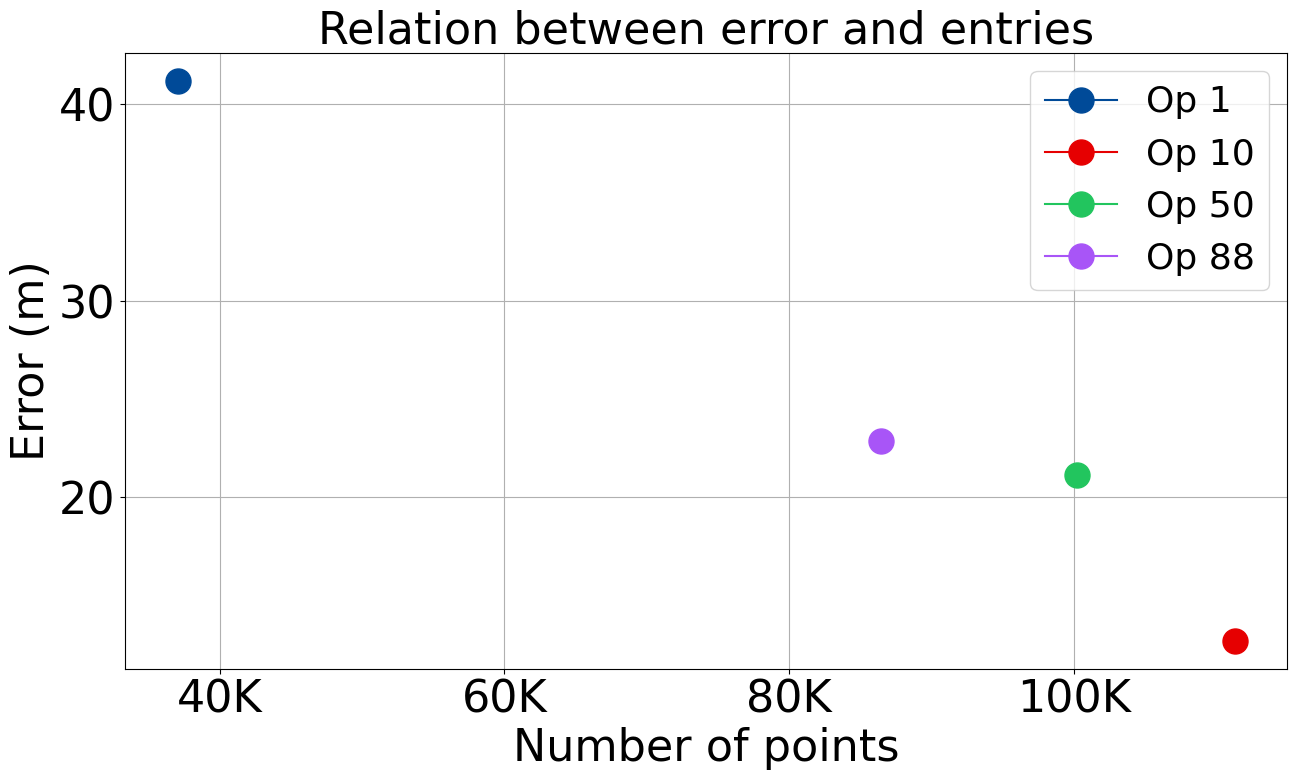

In [15]:


ratio_df = pd.DataFrame({
    'error': errors_df.mean(),
    'entries': entries_df.mean(),
})

from scripts.utils import get_config

color_map = get_config("color_map.json", "operatorId")

print(ratio_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

for i, row in ratio_df.iterrows():
    plt.plot(row['entries'], row['error'], label=f"Op {i}", marker='o', markersize=18, c=color_map[i])

plt.grid(True)
plt.legend()
plt.ylabel('Error (m)')
plt.title('Relation between error and entries')
plt.xlabel('Number of points')


def thousands_formatter(x, pos):
    return f"{x / 1000:.0f}k"


plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{(x / 1000):.0f}K"))

plt.show()